In [1]:
import numpy as np
from pyPolCal.csv_tools import read_csv,match_fits_tags
from pyPolCal.on_sky import write_fits_info_to_csv_psf
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from pyPolCal.utils import process_errors,generate_system_mueller_matrix,process_dataset,process_model
from pyPolCal.fitting import model
from pyPolCal.plotting import plot_data_and_model
from pyPolCal.constants import wavelength_bins
from pyMuellerMat.physical_models.charis_physical_models import HWP_retardance, IMR_retardance,M3_diattenuation,M3_retardance

/home/thomasmc/miniconda3/envs/charisenv_2/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Saturated pixels (counts >40k) detected in image data: 11 saturated pixels
Fitted FWHM left: 6.295835613785727, Fitted FWHM right: 6.182123223992471
Saturated pixels (counts >40k) detected in image data: 14 saturated pixels
Fitted FWHM left: 5.90035080319648, Fitted FWHM right: 5.821975513582631
Saturated pixels (counts >40k) detected in image data: 13 saturated pixels
Fitted FWHM left: 6.174701598008596, Fitted FWHM right: 6.028129616714034
Saturated pixels (counts >40k) detected in image data: 12 saturated pixels
Fitted FWHM left: 6.321889055551161, Fitted FWHM right: 6.186536575500993
Saturated pixels (counts >40k) detected in image data: 10 saturated pixels
Fitted FWHM left: 6.345842180894862, Fitted FWHM right: 6.285372422266181
Saturated pixels (counts >40k) detected in image data: 16 saturated pixels
Fitted FWHM left: 5.950013568858281, Fitted FWHM right: 5.8532806057497755
Saturated pixels (counts >40k) detected in image data: 9 saturated pixels
Fitted FWHM left: 6.496961033674

/home/thomasmc/pyPolCal/pyPolCal/on_sky.py:376: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10,6))


Fitted FWHM left: 5.430858062473053, Fitted FWHM right: 5.414511737461893
Saturated pixels (counts >40k) detected in image data: 18 saturated pixels
Fitted FWHM left: 5.739292277481299, Fitted FWHM right: 5.625745168276805
Saturated pixels (counts >40k) detected in image data: 16 saturated pixels
Fitted FWHM left: 6.173661851732676, Fitted FWHM right: 6.116672985908161
Saturated pixels (counts >40k) detected in image data: 15 saturated pixels
Fitted FWHM left: 5.961461728541993, Fitted FWHM right: 5.935262880098273
Saturated pixels (counts >40k) detected in image data: 20 saturated pixels
Fitted FWHM left: 5.483731995253454, Fitted FWHM right: 5.289005670117153
Saturated pixels (counts >40k) detected in image data: 13 saturated pixels
Fitted FWHM left: 5.981838818217702, Fitted FWHM right: 5.92229971651553
Saturated pixels (counts >40k) detected in image data: 17 saturated pixels
Fitted FWHM left: 5.590407084887047, Fitted FWHM right: 5.550658667054776
Saturated pixels (counts >40k) de

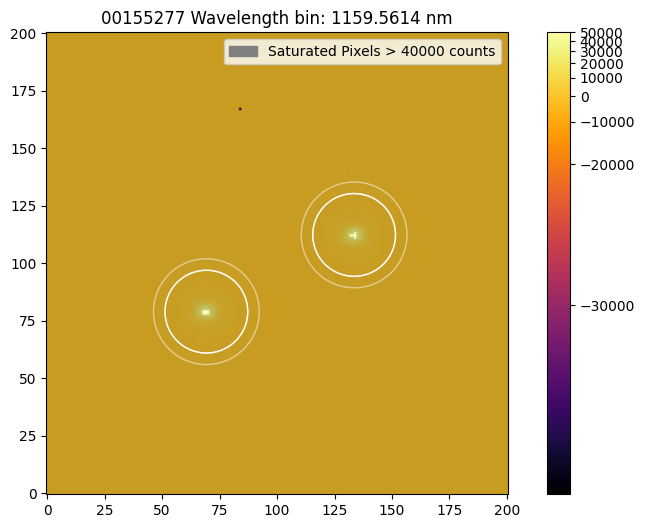

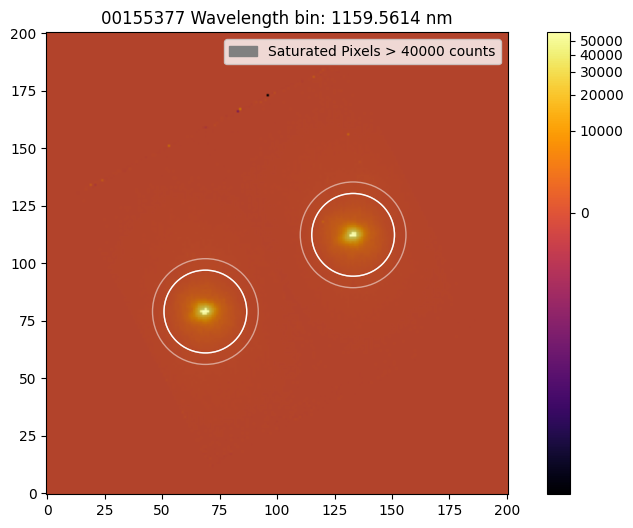

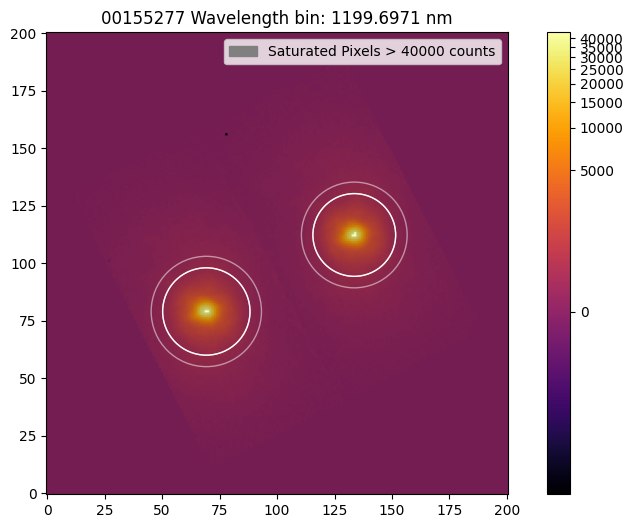

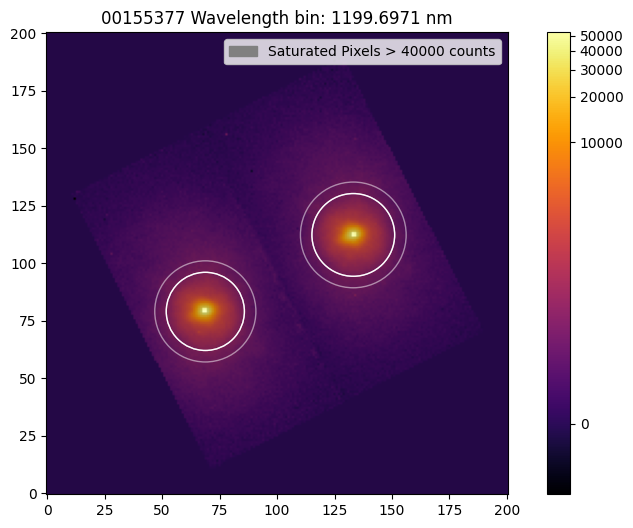

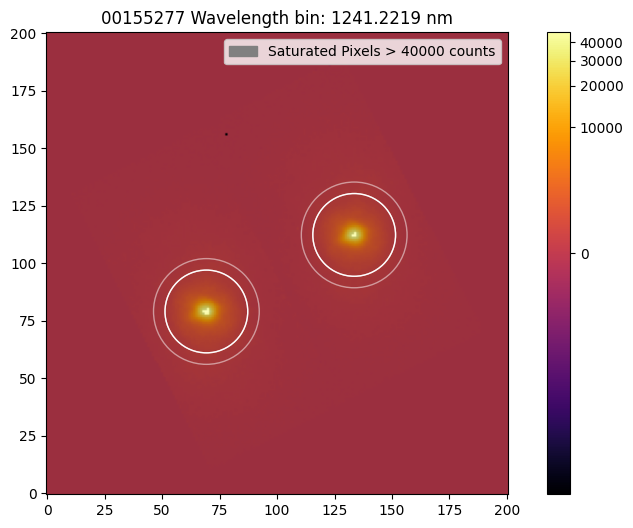

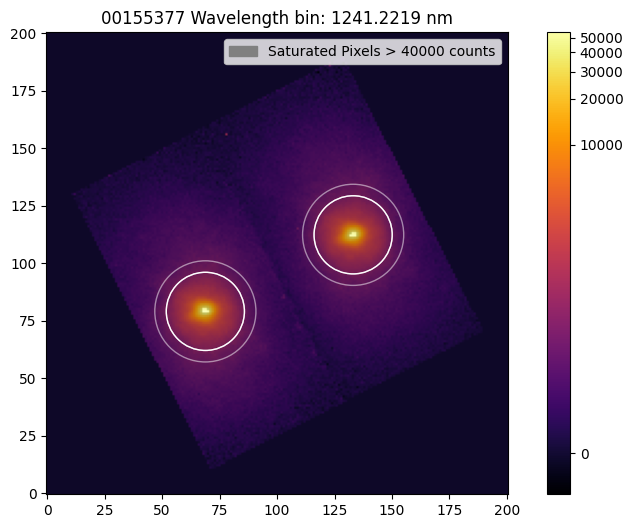

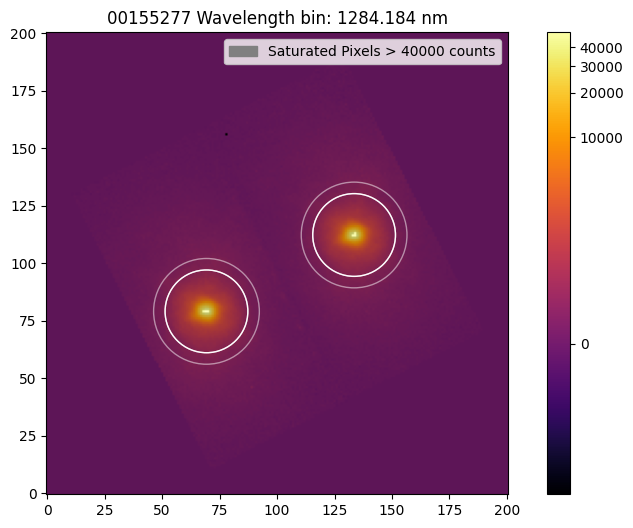

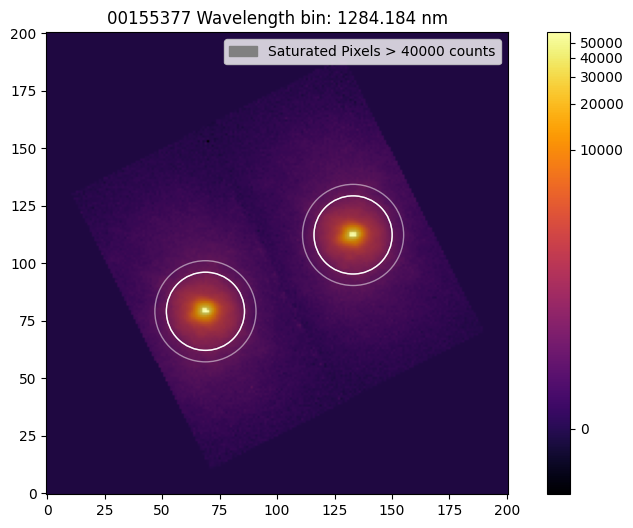

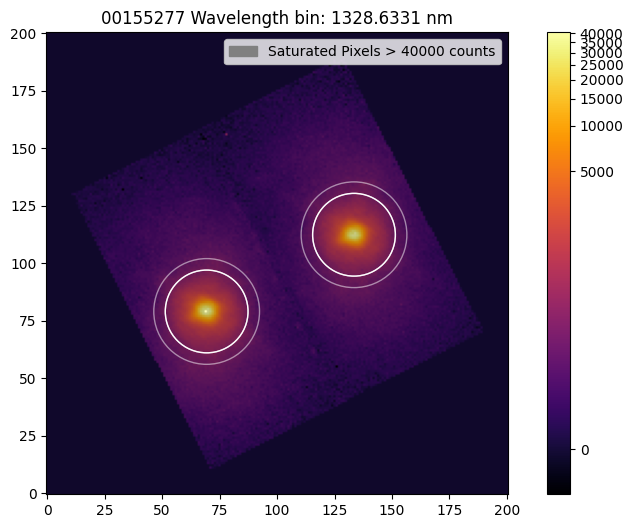

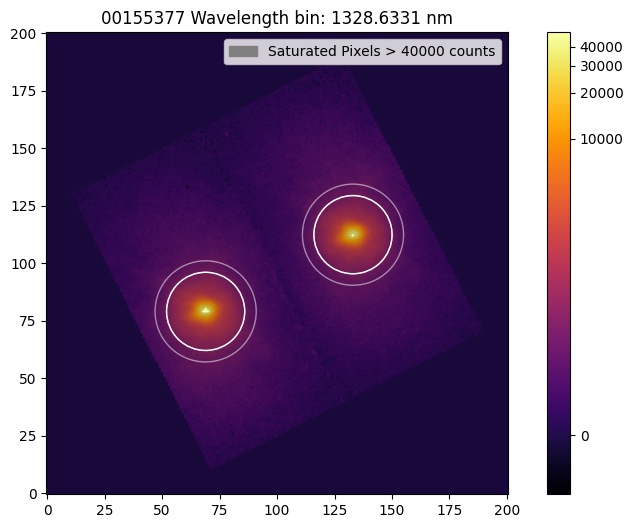

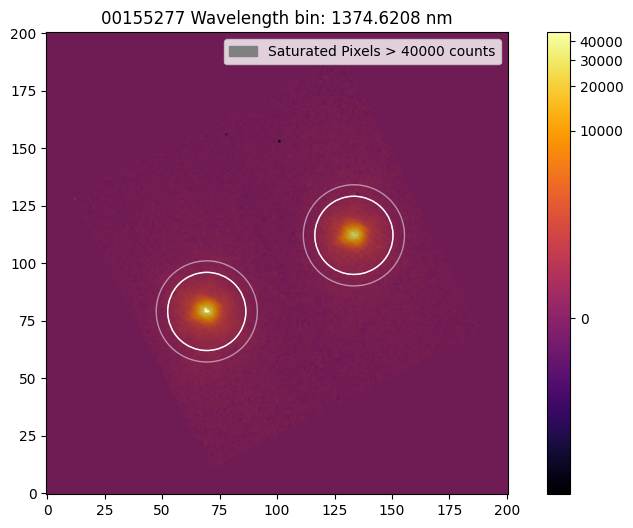

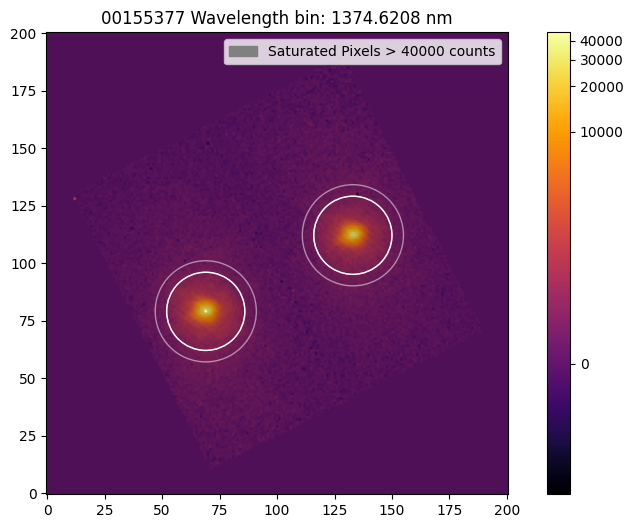

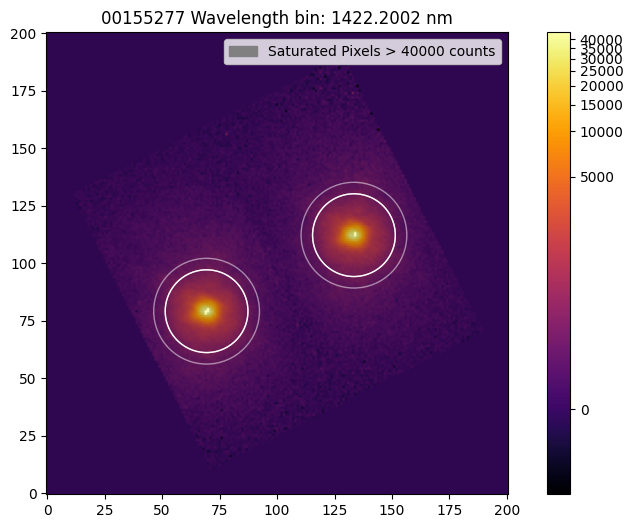

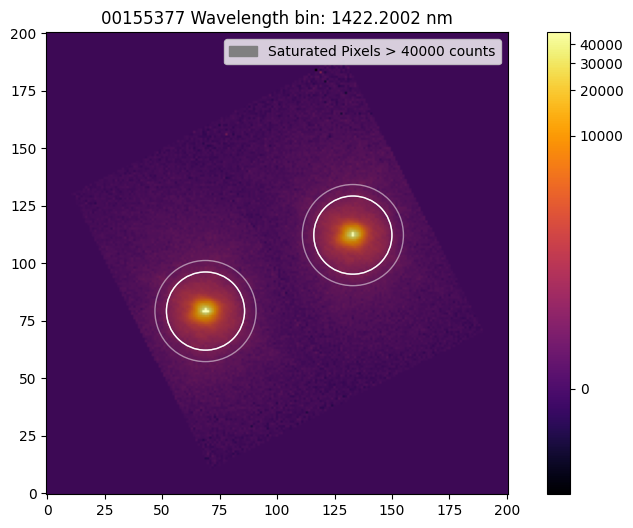

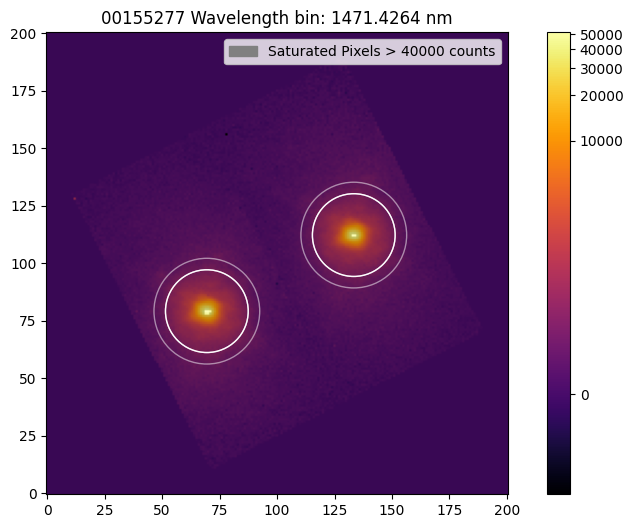

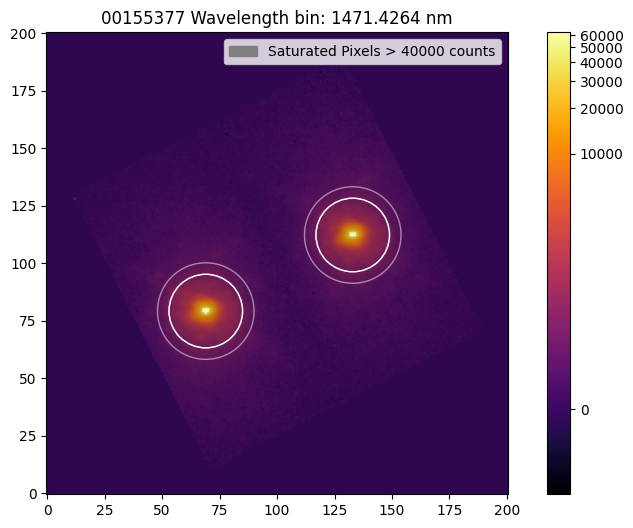

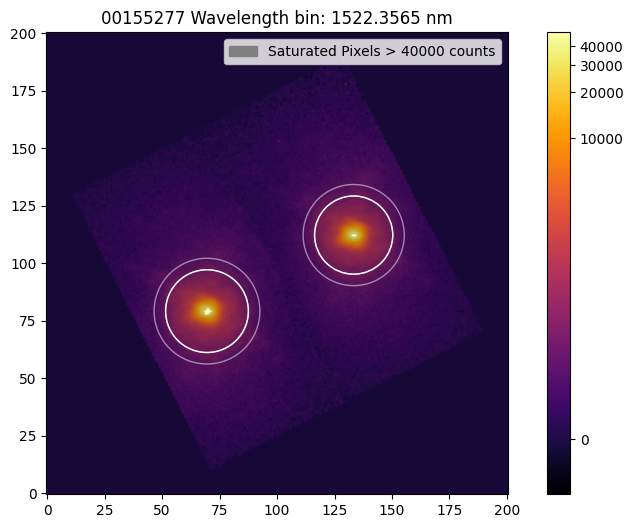

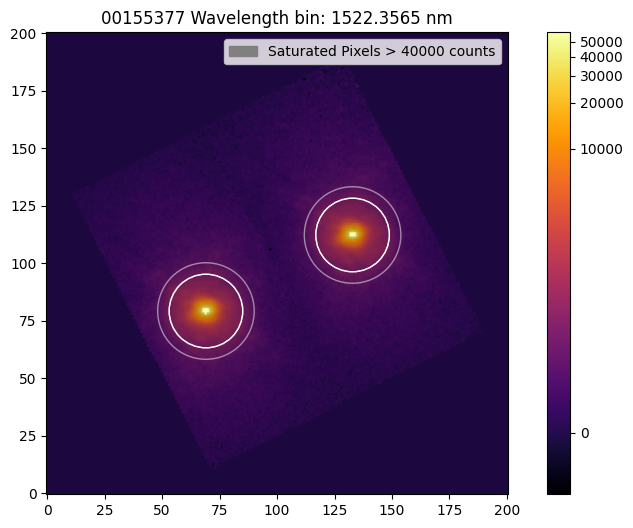

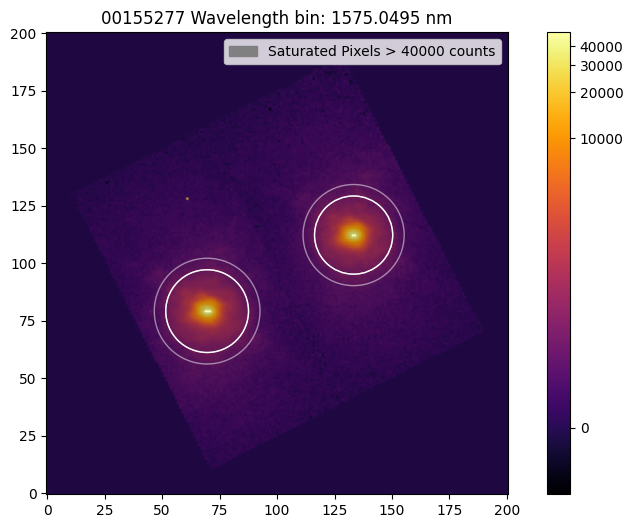

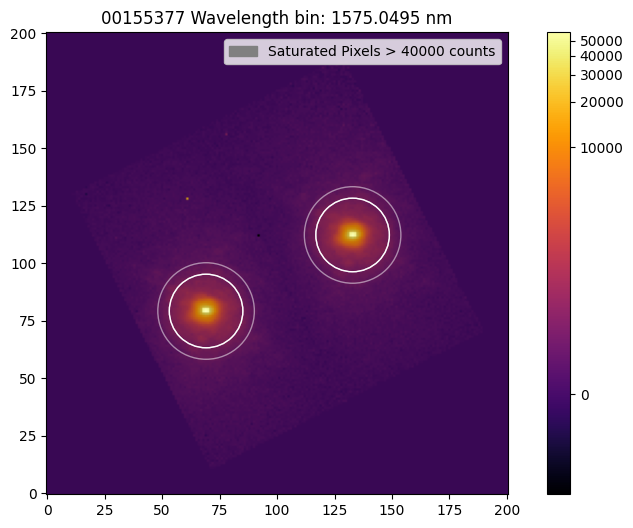

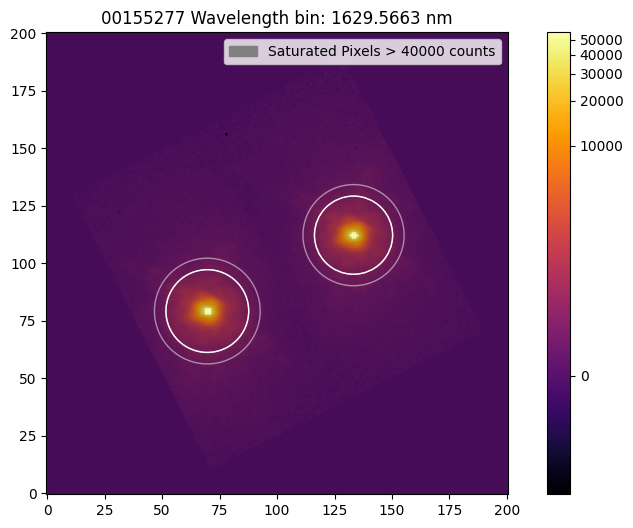

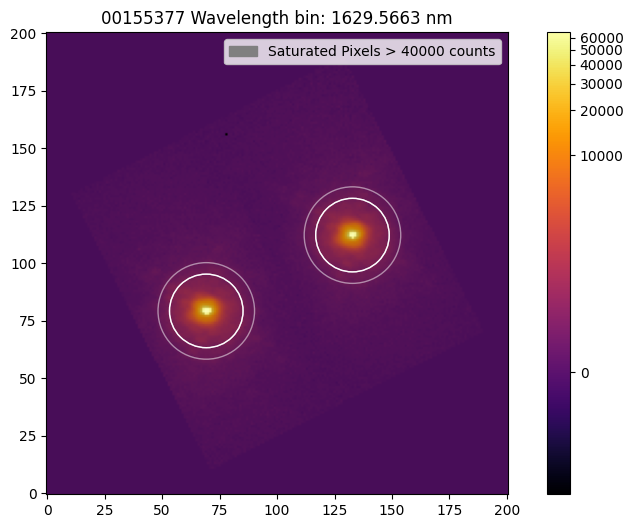

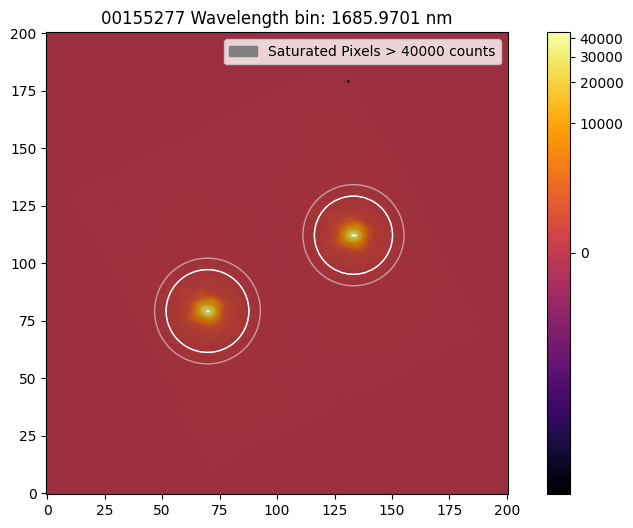

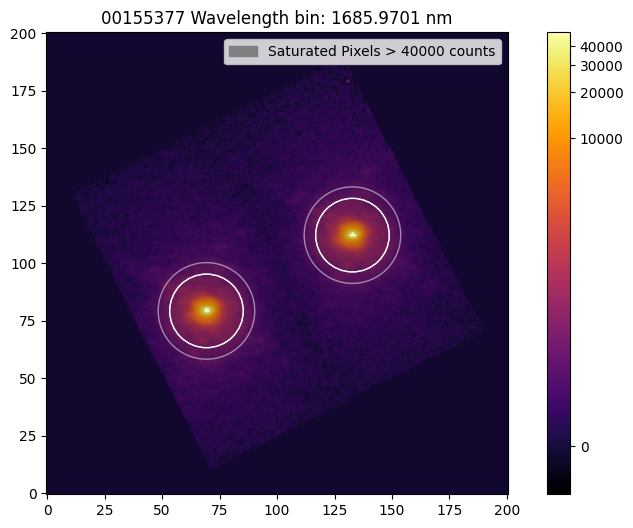

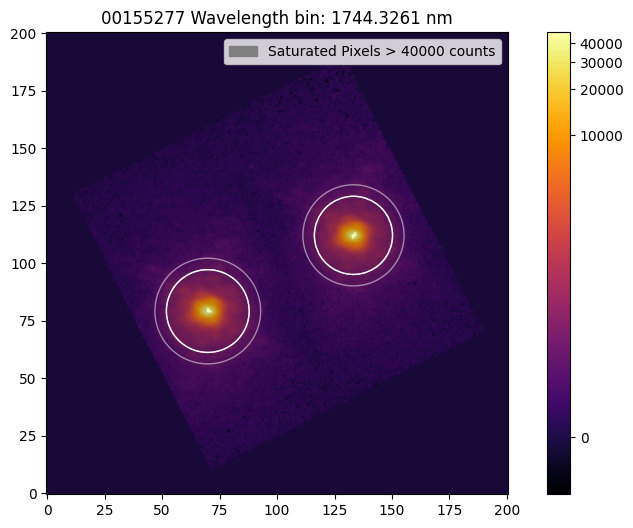

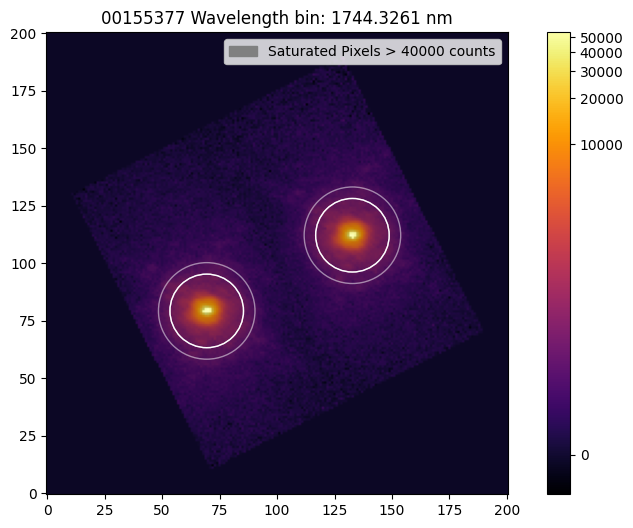

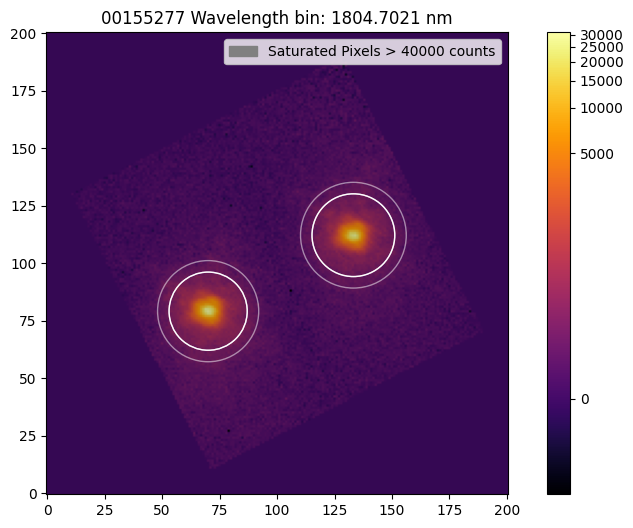

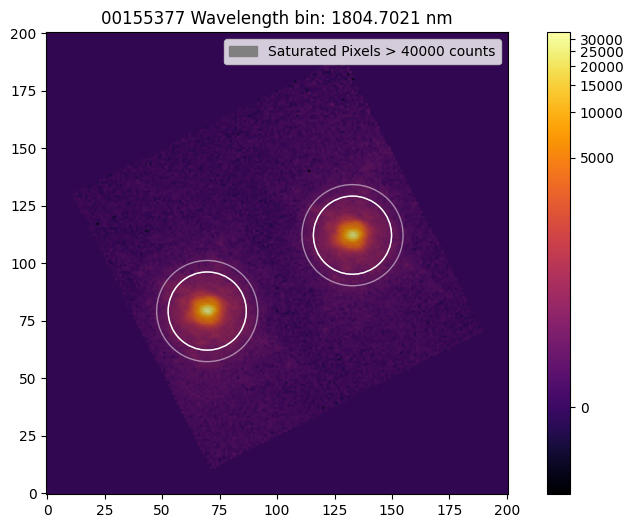

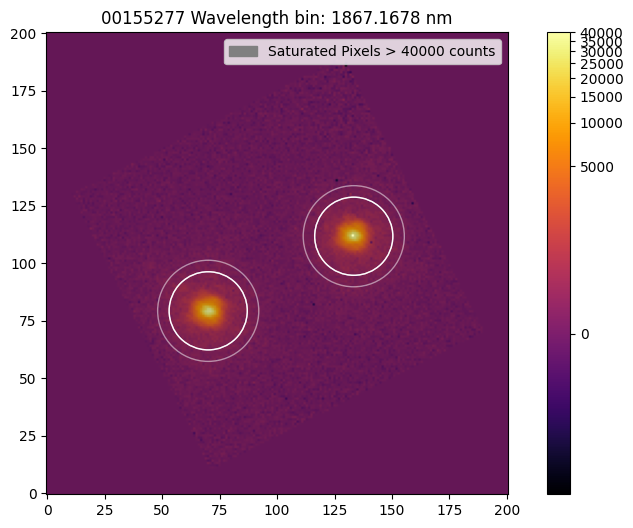

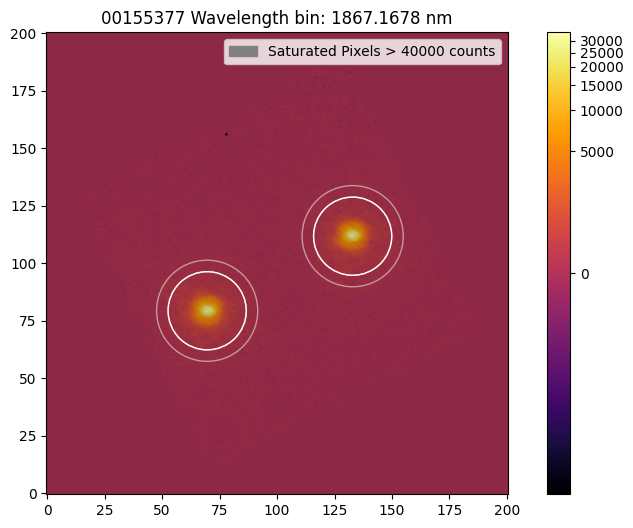

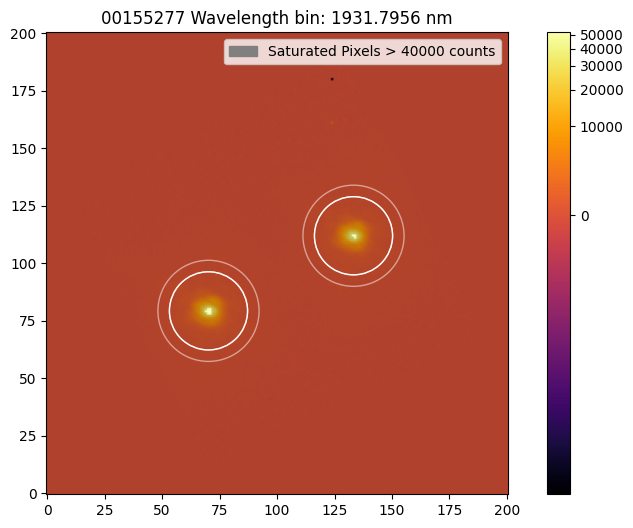

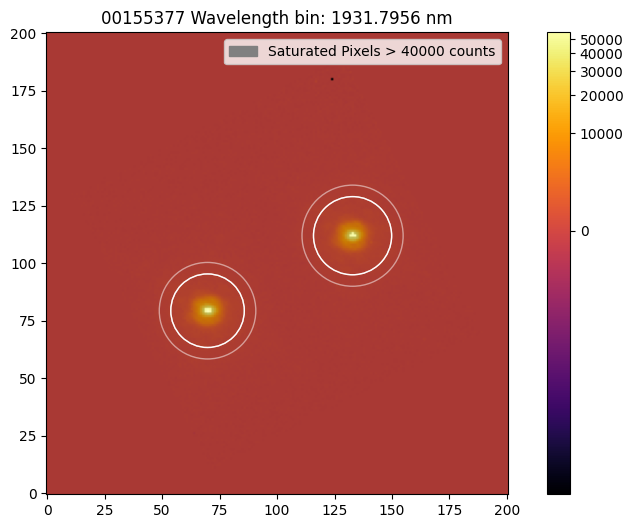

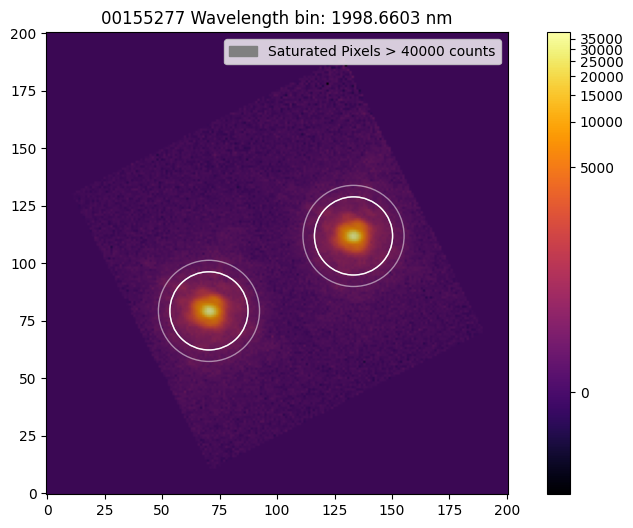

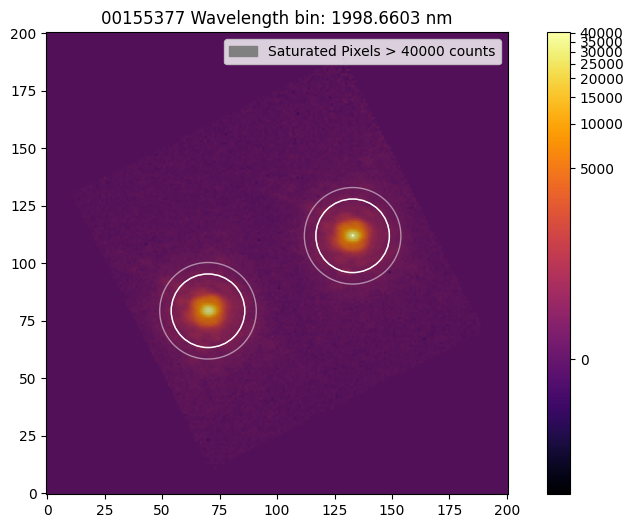

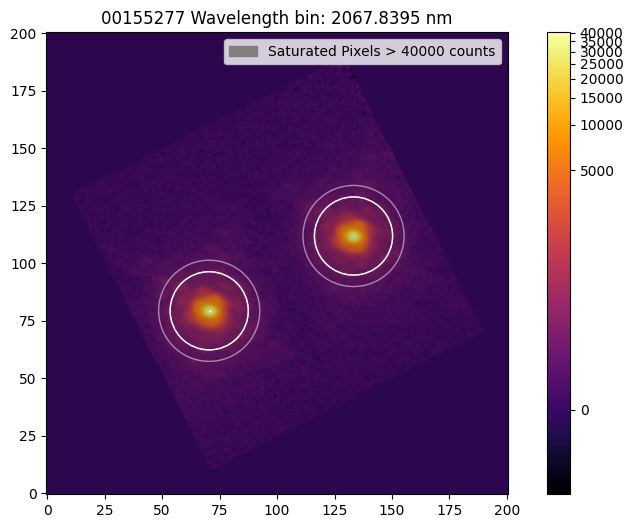

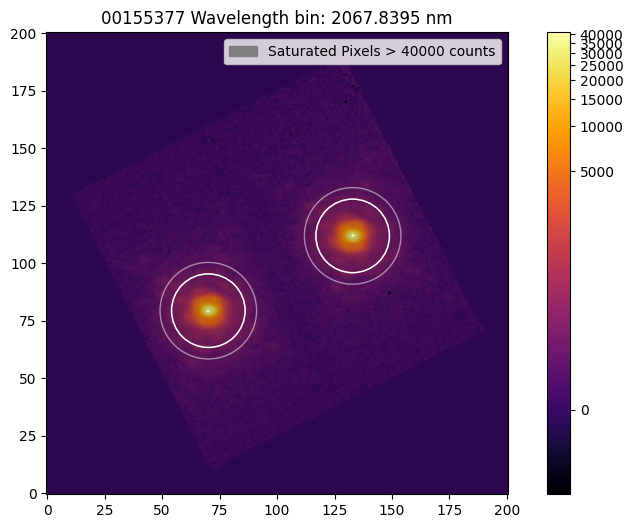

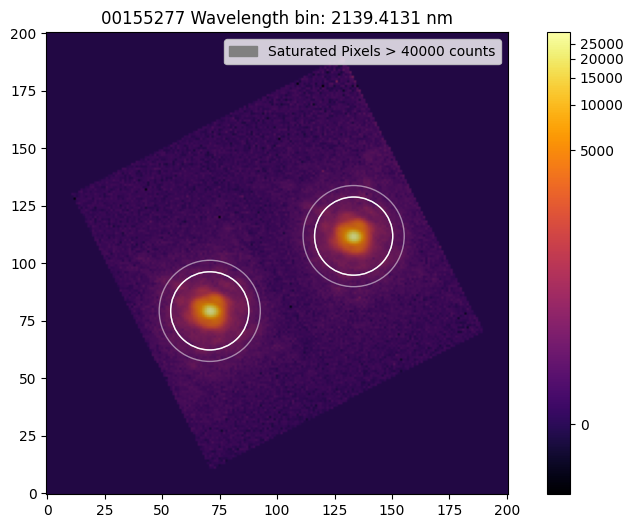

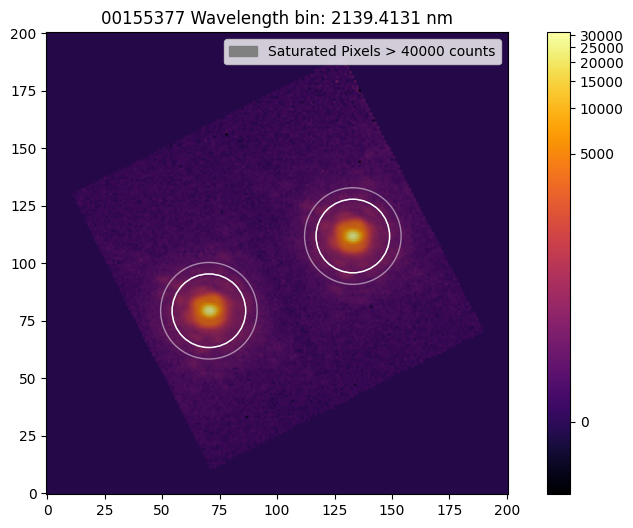

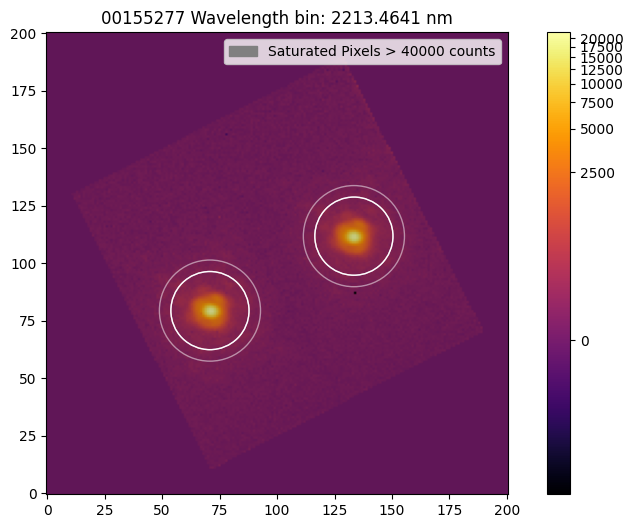

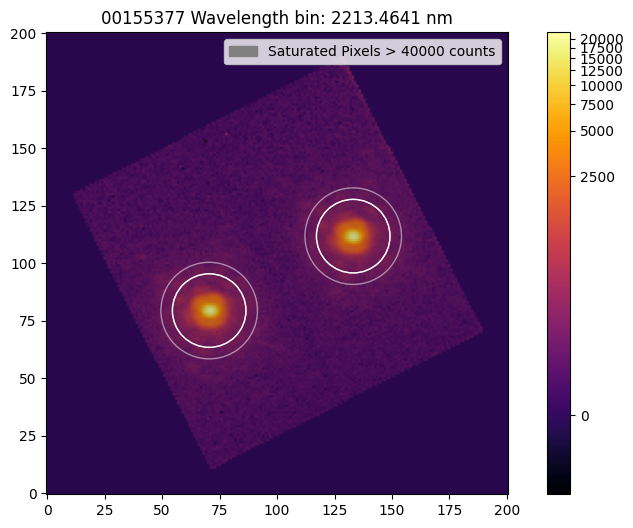

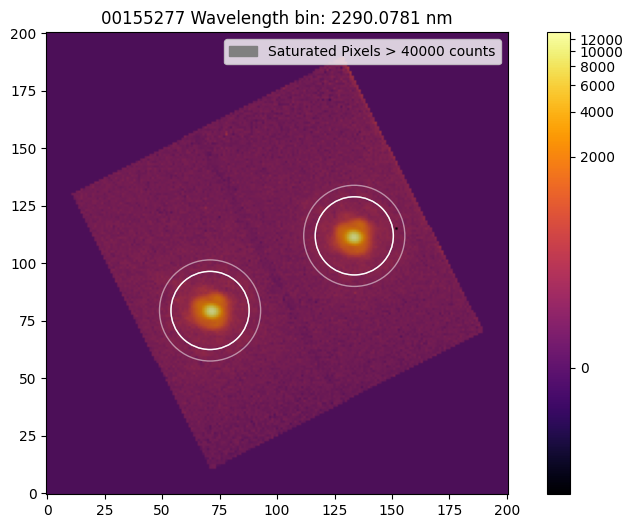

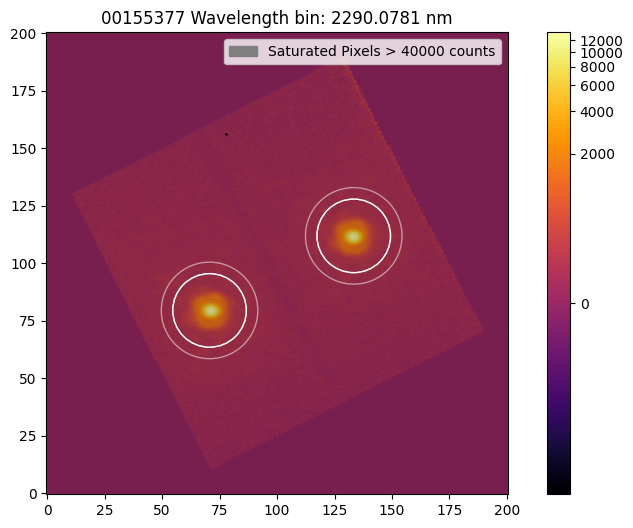

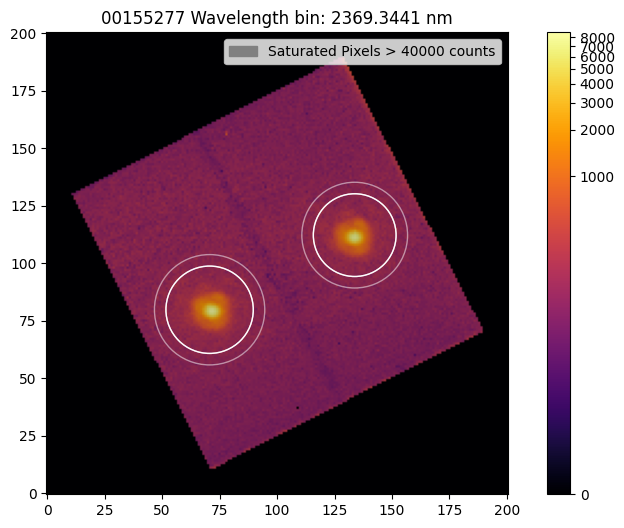

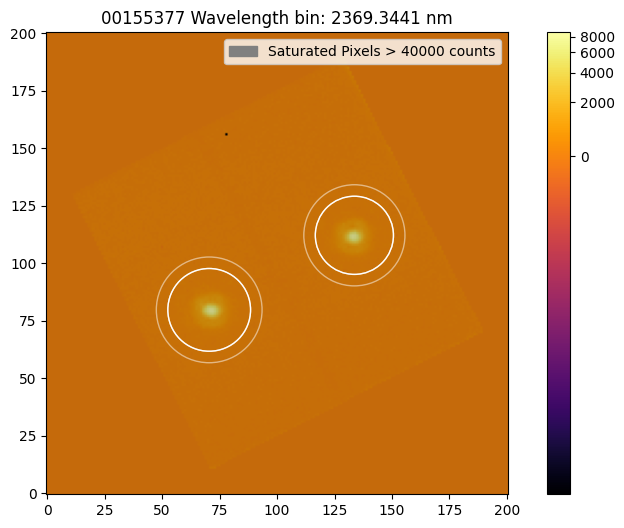

In [3]:
cubedir = '/home/thomasmc/charis_mm_testing/HD30675-pol/flat-cubes'
rawdir = '/home/thomasmc/charis_mm_testing/HD30675-pol/raw'
centroid_guesses = [(70,80), (134,113)]
annuli_radii = ([15.6,25.6],[15.6,25.6]) 
aper_radii = (15.6,15.6) # 3X fwhm
boxssize = 45 # box to search for psf
for bin in range(22):
    csv_out = f'/home/thomasmc/pyPolCal/pyPolCal/CHARIS/datacsvs/onsky_csvs/pol_standards/HD30675/bin{bin}.csv'
    write_fits_info_to_csv_psf(cubedir,csv_out,centroid_guesses,
                               boxssize,bin,raw_cube_path=rawdir, auto_annuli=True,plot_every_x=100, mask=False)

In [4]:
# remove first entry from all csvs
import pandas as pd
for bin in range(22):
    csv_path = f'/home/thomasmc/pyPolCal/pyPolCal/CHARIS/datacsvs/onsky_csvs/pol_standards/HD30675/bin{bin}.csv'
    df = pd.read_csv(csv_path)
    df = df.iloc[1:]
    df.to_csv(csv_path, index=False)


In [2]:
# use serkowski law and known aolp to define s_in for j band
def serkowski(lam, p_max, lam_max, k):
    return p_max * np.exp(-k * np.log(lam_max / lam) ** 2)

# get parameters set
lam_j =wavelength_bins[:6] # j band
p_max = 3.9
lam_max = 0.52*1000 # converting to nm
k = 0.99
aolp_j = np.deg2rad(58)

def input_stokes(lam,p_max,lam_max,k,aolp):
    """
    Returns an input Stokes vector for given wavelength based on 
    Serkowski law and angle of linear polarization.
    
    Parameters
    ----------
    lam : float
        Wavelength in nm.

    p_max : float
        Maximum polarization percentage.

    lam_max : float
        Wavelength at which maximum polarization occurs in nm.

    k : float
        k parameter of the Serkowski law.

    aolp : float
        Angle of linear polarization in radians.

    Returns
    -------
    s_in : ndarray
        Linearly polarized Stokes vector [I, Q, U, 0].

    """
    lam = np.array(lam)
    p = serkowski(lam,p_max,lam_max,k)/100 # convert to fraction
    q = p * np.cos(2*aolp)
    u = p * np.sin(2*aolp)
    s_in = np.array([1,q,u,0])
    return s_in

In [3]:
# modify model function to work with a list of input stokes vectors
from pyPolCal.utils import update_system_mm,parse_configuration,generate_measurement
def model_s_in_array(p, system_parameters, system_mm, configuration_list, p_max,
        lam_max, k, aolp, process_model = None):    
    """Returns simulated L/R wollaston beam intensities for a given set of parameters based on
    parameter values, a dictionary detailing those values based on pyMuellerMat, 
    a pyMuellerMat system Mueller matrix, and a list of configurations for the 
    system Mueller matrix.

    Parameters
    ----------
    p : list of float
        List of parameter values. One list of values per parameter.
    
    system_parameters : list of [str, str]
        List of ['component_name', 'parameter_name'] pairs corresponding to `p`.
        For example, [['Polarizer', 'Theta'], ['Polarizer', 'Phi']] if your p
        is two lists of parameters Theta and Phi for a Polarizer component.

    system_mm : pyMuellerMat system Mueller matrix object
        Mueller matrix model of the optical system. Any parameters
        that are specified in p and system_parameters will be replaced.

    configuration_list : list of dict
        Each dict will update parameters of your current system_mm 
        to generate measurements. For example, if you want 9 HWP angles
        and one derotator angle, each config dict will have this form:
        {"hwp": {"theta": hwp_angle},
        "image_rotator": {"theta": 45.0}
        Append each unique configuration to your configuration_list.

    p_max : float
        Maximum polarization percentage.
    
    lam_max : float
        Wavelength at which maximum polarization occurs in nm.

    k : float
        k parameter of the Serkowski law.

    aolp : float
        Angle of linear polarization in radians.


    process_model : callable, optional
        Converts output intensities to double differences. 

    Returns
    --------
    np.ndarray
        Simulated intensities [L,R,L,R..]

    """
    
    # Default s_in if not provided

    # Update the system Mueller matrix with parameters that we're fitting
    system_mm = update_system_mm(p, system_parameters, system_mm)

    # Generate a model dataset
    output_intensities = []

    # Save the parameters necessary to switch between o and e beam
    o_beam_values, wollaston_beam_keyword = parse_configuration({'wollaston': {'beam': 'o'}})
    e_beam_values, wollaston_beam_keyword = parse_configuration({'wollaston': {'beam': 'e'}})

    for i in range(len(configuration_list)):
        values, keywords = parse_configuration(configuration_list[i])
        system_mm = update_system_mm(values, keywords, system_mm)

        # Compute the intensity for the ordinary beam
        system_mm = update_system_mm(o_beam_values, wollaston_beam_keyword, system_mm)

        # get wavelength from configuration
        lam = configuration_list[i]['M3']['wavelength']
        s_in = input_stokes(lam,p_max,lam_max,k,aolp)
        s_out_o = generate_measurement(system_mm, s_in)
        o_intensity = s_out_o[0]

        # Compute the intensity for the extraordinary beam
        system_mm = update_system_mm(e_beam_values, wollaston_beam_keyword, system_mm)
        s_out_e = generate_measurement(system_mm, s_in)
        e_intensity = s_out_e[0]

        output_intensities.append(o_intensity)
        output_intensities.append(e_intensity)

    # Optionally parse the intensities into another variable (e.g., normalized difference)
    if process_model is not None:
        output_intensities = process_model(output_intensities)

    # Convert intensities list to numpy arrays
    output_intensities = np.array(output_intensities)

    return output_intensities


In [4]:
# get values for j band
from pyPolCal.csv_tools import read_csv_physical_model_all_bins
csvs_j = '../datacsvs/onsky_csvs/pol_standards/HD30675-J'
interleaved_values_j, interleaved_stds_j, interleaved_configs_j = read_csv_physical_model_all_bins(csvs_j,m3=True)
stds_j = process_errors(interleaved_stds_j,interleaved_values_j)[::2]
diffs_j = process_dataset(interleaved_values_j)[::2]
configs_j = interleaved_configs_j
print(configs_j[0])

Expected 22 CSV files for all wavelength bins, but found 6
{'hwp': {'theta': 94.76, 'wavelength': 1159.5614}, 'image_rotator': {'theta': 88.90286, 'wavelength': 1159.5614}, 'altitude_rot': {'pa': -48.79694762}, 'M3': {'wavelength': 1159.5614}, 'parang_rot': {'pa': 91.79203064543496}, 'wollaston': {'wavelength': 1159.5614}}


In [5]:
# DEFINING CUSTOM MM FUNCS

from pyPolCal.csv_tools import model_data
from pyPolCal.mm_registry import register_mm_function
import numpy as np
from pyPolCal.constants import wavelength_bins
from pyMuellerMat.common_mm_functions import elliptical_retarder_function , wollaston_prism_function

# Retreiving fits
wavelength_fits_dir = '/home/thomasmc/pyPolCal/pyPolCal/tutorial_notebooks/CHARIS_fitting_tutorial/wavelength_fit_results' # path to fitted p dicts
wavelength_fits_df = model_data(wavelength_fits_dir) # saving to DataFrame
derotator_phi_h = wavelength_fits_df['image_rotator_phi_h'].to_numpy() # linear h retardance
derotator_phi_45 = wavelength_fits_df['image_rotator_phi_45'].to_numpy() # linear 45 retardance
derotator_phi_r = wavelength_fits_df['image_rotator_phi_r'].to_numpy() # circular retardance
wollaston_eta = wavelength_fits_df['wollaston_eta'].to_numpy()

@register_mm_function()
def fitted_derotator_function_12_28_2025(wavelength=500): # Only keyword arguments!
    phi_h = derotator_phi_h
    phi_45 = derotator_phi_45
    phi_r = derotator_phi_r

    # Interpolating retardance as a function of wavelength 
    phi_h_interp = np.interp(wavelength, wavelength_bins, phi_h)
    phi_45_interp = np.interp(wavelength, wavelength_bins, phi_45)
    phi_r_interp = np.interp(wavelength, wavelength_bins, phi_r)

    # using pyMuellerMat's elliptical retarder function
    return elliptical_retarder_function(phi_h_interp, phi_45_interp, phi_r_interp)

@register_mm_function()
def fitted_wollaston_function_12_28_2025(beam='o',wavelength=500): # Only keyword arguments!
    eta = wollaston_eta

    # Interpolating retardance as a function of wavelength
    eta_interp = np.interp(wavelength, wavelength_bins, eta)

    # using pyMuellerMat's elliptical retarder function
    return wollaston_prism_function(beam=beam,eta=eta_interp)

Mueller matrix function 'fitted_derotator_function_12_28_2025' is already registered. Overwriting.
Mueller matrix function 'fitted_wollaston_function_12_28_2025' is already registered. Overwriting.


In [6]:
# generate model 
from pyPolCal.csv_tools import model_data
from pyPolCal.utils import parse_configuration
wavelength_bins = np.array([1159.5614, 1199.6971, 1241.2219, 1284.184 , 1328.6331, 1374.6208,
1422.2002, 1471.4264, 1522.3565, 1575.0495, 1629.5663, 1685.9701,
1744.3261, 1804.7021, 1867.1678, 1931.7956, 1998.6603, 2067.8395,
2139.4131, 2213.4641, 2290.0781, 2369.3441])
wavelength_bin = 15 # placeholder
offset_imr = 1.384e-02
offset_hwp = -3.168e-02
imr_theta = 0 # placeholder 
hwp_theta = 0 # placeholder
# Past fits from scipy minimize on the naive fits
d = 259.12694
wsio2 = 1.638
wmgf2 = 1.28
m3_diat = M3_diattenuation(wavelength_bins[4])
m3_ret = M3_retardance(wavelength_bins[4])
m1, b1, m2, b2 =(1.864,13.57,2.028,14.16)

# Define instrument configuration as system dictionary

system_dict = {
        "components" : {
            "wollaston" : {
            "type" : "fitted_wollaston_function_12_28_2025",
            "properties" : {"beam": 'o'}, 
            "tag": "internal",
            },
            "image_rotator" : {
                "type" : "fitted_derotator_function_12_28_2025",
                "properties" : {"wavelength":wavelength_bins[wavelength_bin]},
                "tag": "internal",
            },
            "hwp" : {
                "type" : "two_layer_HWP_function",
                "properties" : {"wavelength": wavelength_bins[wavelength_bin], "w_SiO2": wsio2, "w_MgF2": wmgf2, "theta":hwp_theta, "delta_theta": offset_hwp},
                "tag": "internal",
            },
            "altitude_rot" : {
                "type" : "rotator_function",
                "properties" : {"pa":77},
                "tag":"internal",
            },
            "M3" : {
                "type" : "SUBARU_M3_function",
                "properties" : {"wavelength": wavelength_bins[wavelength_bin], "m1":m1, "b1":b1, "m2":m2, "b2":b2},
                "tag": "internal",
            },
            "parang_rot" : {
                "type" : "rotator_function",
                "properties" : {"pa":39},
                "tag":"internal",
            },
            }
    }

# define initial guess and bounds
p0_dict = {
    "M3" : 
        {"m1":m1,"b1":b1, "m2":m2,"b2":b2}
}

# generate modeled left and right wollaston intensities
system_mm = generate_system_mueller_matrix(system_dict)
p, pkeys = parse_configuration(p0_dict) # put into correct form for model function
dds = model_s_in_array(p,pkeys,system_mm,configs_j,p_max,lam_max,k,aolp_j,process_model=process_model)[::2]


In [7]:
# generate s
s_res_by_wavelength = []
for bin in range(6):
    # mask per bin
    bin_mask = []
    for dict in configs_j[::2]:
        if dict['hwp']['wavelength'] == wavelength_bins[bin]:
            bin_mask.append(True)
        else:
            bin_mask.append(False)

    # apply mask
    double_diffs_bin = diffs_j[bin_mask]
    double_diffs_stds_bin = stds_j[bin_mask]
    config_lists_bin = np.array(configs_j[::2])[bin_mask]
    modeled_double_differences_bin = dds[bin_mask]
    # calculate s_res as in appendix E of SPHERE cal paper
    residuals = (double_diffs_bin*100-modeled_double_differences_bin*100)
    s_res = np.sqrt(np.sum(residuals**2)/(len(diffs_j[bin_mask])))
    s_res_by_wavelength.append(s_res)

Text(0.5, 1.0, 's_res by wavelength bin for HD30675 J band')

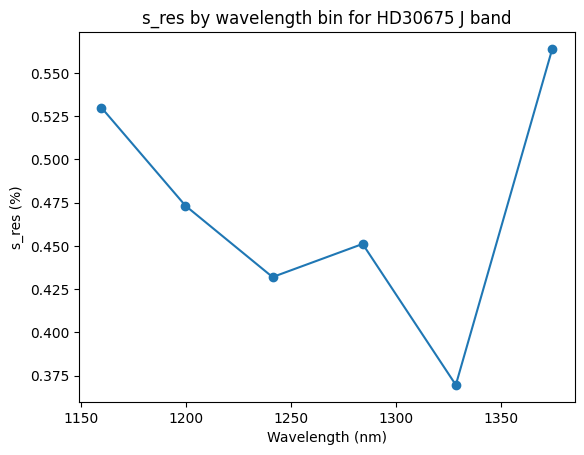

In [8]:
plt.plot(lam_j,s_res_by_wavelength,'o-')
plt.xlabel('Wavelength (nm)')
plt.ylabel('s_res (%)')
plt.title('s_res by wavelength bin for HD30675 J band')

In [9]:
# now use H band
aolp_h = 61
lam_h = wavelength_bins[8:14]
csvs_h = '/home/thomasmc/pyPolCal/pyPolCal/CHARIS/datacsvs/onsky_csvs/pol_standards/HD30675-H'
interleaved_values_h, interleaved_stds_h, interleaved_configs_h = read_csv_physical_model_all_bins(csvs_h,m3=True)
stds_h = process_errors(interleaved_stds_h,interleaved_values_h)[::2]
diffs_h = process_dataset(interleaved_values_h)[::2]
configs_h = interleaved_configs_h

# generate model
dds_h = model_s_in_array(p,pkeys,system_mm,configs_h,p_max,lam_max,k,aolp_h,process_model=process_model)[::2]
print(configs_h)

Expected 22 CSV files for all wavelength bins, but found 6
[{'hwp': {'theta': 94.76, 'wavelength': 1522.3565}, 'image_rotator': {'theta': 88.90286, 'wavelength': 1522.3565}, 'altitude_rot': {'pa': -48.79694762}, 'M3': {'wavelength': 1522.3565}, 'parang_rot': {'pa': 91.79203064543496}, 'wollaston': {'wavelength': 1522.3565}}, {'hwp': {'theta': 139.68, 'wavelength': 1522.3565}, 'image_rotator': {'theta': 88.89295, 'wavelength': 1522.3565}, 'altitude_rot': {'pa': -48.75875485}, 'M3': {'wavelength': 1522.3565}, 'parang_rot': {'pa': 91.77021868915728}, 'wollaston': {'wavelength': 1522.3565}}, {'hwp': {'theta': 117.11, 'wavelength': 1522.3565}, 'image_rotator': {'theta': 88.87652, 'wavelength': 1522.3565}, 'altitude_rot': {'pa': -48.7209022}, 'M3': {'wavelength': 1522.3565}, 'parang_rot': {'pa': 91.74819257646824}, 'wollaston': {'wavelength': 1522.3565}}, {'hwp': {'theta': 162.08, 'wavelength': 1522.3565}, 'image_rotator': {'theta': 88.85222, 'wavelength': 1522.3565}, 'altitude_rot': {'pa': 

In [10]:
# generate s
s_res_by_wavelength_h = []
for bin in range(8,14):
    # mask per bin
    bin_mask = []
    for dict in configs_h[::2]:
        if dict['hwp']['wavelength'] == wavelength_bins[bin]:
            bin_mask.append(True)
        else:
            bin_mask.append(False)

    # apply mask
    double_diffs_bin = diffs_h[bin_mask]
    double_diffs_stds_bin = stds_h[bin_mask]
    config_lists_bin = np.array(configs_h[::2])[bin_mask]
    modeled_double_differences_bin = dds_h[bin_mask]
    # calculate s_res as in appendix E of SPHERE cal paper
    residuals = (double_diffs_bin*100-modeled_double_differences_bin*100)
    s_res = np.sqrt(np.sum(residuals**2)/(len(diffs_h[bin_mask])))
    s_res_by_wavelength_h.append(s_res)

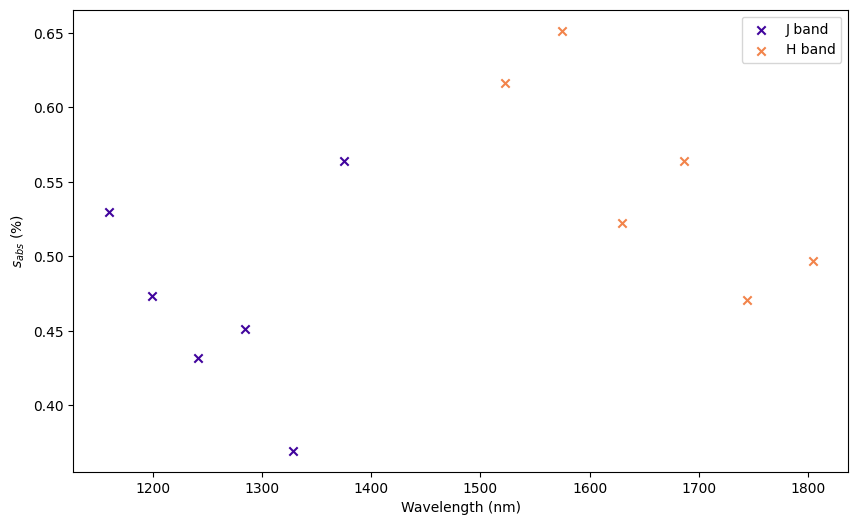

In [11]:

s_j_h = np.concatenate((s_res_by_wavelength,s_res_by_wavelength_h))
lam_j_h = np.concatenate((lam_j,lam_h))

fig, ax = plt.subplots(figsize=(10,6))
cmap = plt.get_cmap('plasma')
c1 = cmap(0.1)
c2 = cmap(0.7)
ax.scatter(lam_j,s_res_by_wavelength,marker='x',color=c1,label='J band')
ax.scatter(lam_h,s_res_by_wavelength_h,marker='x',color=c2,label='H band')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$s_{abs}$ (%)')
ax.legend()
#plt.title('Polarimetric Accuracy for HD30675 Polarized Standard Star')
#plt.savefig('/home/thomasmc/charis_mm_testing/HD30675-pol/plots/s_res_j_h.png',dpi=600, bbox_inches='tight')